# 04 · Data validation and preprocessing

**Single responsibility:** reject corrupt inputs, audit duplicates and brightness, then freeze the processed manifest and tf.data contract

Run after the preceding numbered notebook unless the inputs already exist. Every generated artifact is written outside the notebook so this stage is reproducible.


In [1]:
from pathlib import Path
import sys

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'configs/base.yaml').exists())
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from vww_esp32.config import load_config, resolve_paths, seed_everything

config, ROOT = load_config(ROOT / 'configs/base.yaml')
paths = resolve_paths(config, ROOT)
seed_everything(config['project']['seed'])
ROOT


PosixPath('/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32')

In [2]:
import pandas as pd
from vww_esp32.data import validate_images

manifest = pd.read_csv(paths['interim'] / 'manifest.csv')
validated = validate_images(manifest)
validated.groupby(['split', 'valid']).size().rename('images').to_frame()

/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Validate: 100%|██████████| 16000/16000 [00:03<00:00, 4420.37it/s]


,,images
split,valid,
test,True,2000
train,True,12000
val,True,2000


In [3]:
from vww_esp32.data import sha256_file

valid = validated[validated.valid].copy()
valid['sha256'] = valid.image_path.map(sha256_file)
duplicates = valid[valid.duplicated('sha256', keep=False)].sort_values('sha256')
print(f'Exact duplicate rows: {len(duplicates):,}')
duplicates[['split', 'image_id', 'sha256']].head(10)

Exact duplicate rows: 0


,split,image_id,sha256


Cross-split exact duplicates are a leakage risk. COCO image IDs should already be unique; the content hash is a defensive check.

In [4]:
cross_split = duplicates.groupby('sha256').split.nunique() if len(duplicates) else pd.Series(dtype=int)
assert not (cross_split > 1).any(), 'Exact image content leaks across splits'

In [5]:
import numpy as np
from PIL import Image, ImageStat

def image_quality(path):
    with Image.open(path) as image:
        gray = image.convert('L').resize((32, 32))
        stat = ImageStat.Stat(gray)
        return pd.Series({'brightness': stat.mean[0], 'contrast': stat.stddev[0]})

quality = valid.image_path.map(image_quality)
quality = pd.DataFrame(quality.tolist(), index=valid.index)
valid = valid.join(quality)
valid.groupby(['split', 'label'])[['brightness', 'contrast']].agg(['mean', 'std']).round(1)

brightness       contrast      
                  mean   std     mean   std
split label                                
test  0          114.9  29.3     51.4  14.0
      1          113.4  30.3     53.3  13.5
train 0          115.4  29.5     51.9  14.5
      1          113.8  30.6     53.4  13.8
val   0          115.3  28.9     51.6  13.4
      1          113.3  30.4     53.1  13.7

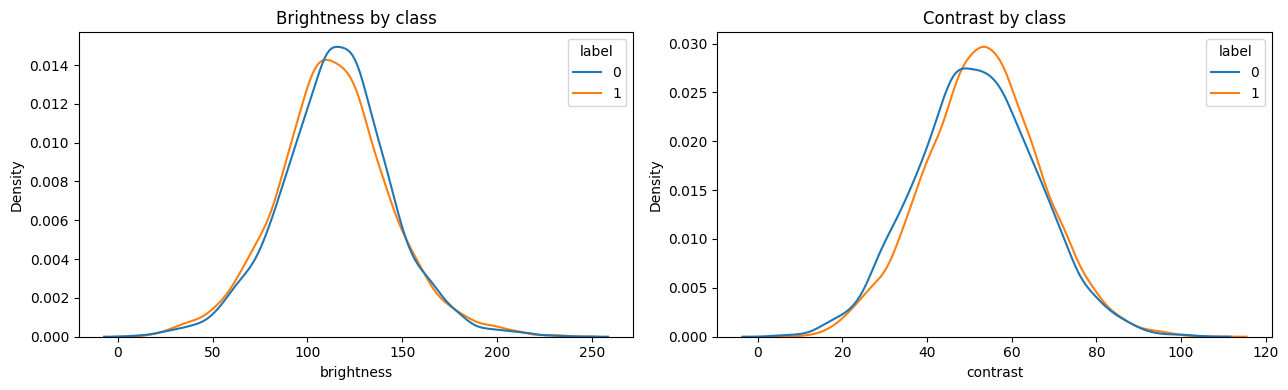

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.kdeplot(data=valid, x='brightness', hue='label', common_norm=False, ax=axes[0])
sns.kdeplot(data=valid, x='contrast', hue='label', common_norm=False, ax=axes[1])
axes[0].set_title('Brightness by class')
axes[1].set_title('Contrast by class')
plt.tight_layout()

In [7]:
processed_manifest = paths['processed'] / 'manifest.csv'
valid.drop(columns=['valid', 'validation_error'], errors='ignore').to_csv(processed_manifest, index=False)
print(valid.groupby(['split', 'label']).size())
print(processed_manifest)

split  label
test   0        1019
       1         981
train  0        6000
       1        6000
val    0        1011
       1         989
dtype: int64
/Volumes/VM_SSD/Machine Learning/visual-wake-word-esp32/data/processed/manifest.csv


In [8]:
from vww_esp32.preprocessing import make_dataset, split_manifest

splits = split_manifest(valid)
train_ds = make_dataset(splits['train'], tuple(config['preprocessing']['image_size']), config['preprocessing']['batch_size'], training=True, seed=config['project']['seed'])
images, labels = next(iter(train_ds))
assert images.shape[1:] == (96, 96, 3)
assert images.dtype.name == 'float32'
{'image_batch': images.shape, 'labels': labels.shape, 'pixel_range': (float(images.numpy().min()), float(images.numpy().max()))}

{'image_batch': TensorShape([64, 96, 96, 3]),
 'labels': TensorShape([64]),
 'pixel_range': (0.0, 255.0)}